In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Matplotlib is building the font cache; this may take a moment.


In [4]:

#This notebook preprocesses NASA OMNI space weather data for the ISRO PS14 project.

#The workflow includes:
#- Reading the raw dataset
#- Understanding the variables
#- Checking data quality
#- Identifying missing/fill values
#- Converting timestamps
#- Preparing the dataset for merging with GOES data

In [5]:
columns = [
    "YEAR",
    "DOY",
    "Hour",
    "Bz",
    "Density",
    "Vsw",
    "FlowPressure",
    "Kp",
    "Dst",
    "F107",
    "AE"
]

In [6]:
df = pd.read_csv(
    "data/raw/omni2_0FlVCwqiM6.lst",
    sep=r"\s+",
    names=columns
)

df.head()

,YEAR,DOY,Hour,Bz,Density,Vsw,FlowPressure,Kp,Dst,F107,AE
0,2013,1,0,-0.2,1.9,358.0,0.49,7,4,113.9,11
1,2013,1,1,-0.2,2.1,355.0,0.52,7,4,113.9,10
2,2013,1,2,-0.1,1.8,359.0,0.44,7,3,113.9,8
3,2013,1,3,0.2,1.9,352.0,0.44,3,2,113.9,9
4,2013,1,4,0.6,2.0,351.0,0.47,3,1,113.9,12


In [7]:
print("Shape:", df.shape)

Shape: (114192, 11)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114192 entries, 0 to 114191
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   YEAR          114192 non-null  int64  
 1   DOY           114192 non-null  int64  
 2   Hour          114192 non-null  int64  
 3   Bz            114192 non-null  float64
 4   Density       114192 non-null  float64
 5   Vsw           114192 non-null  float64
 6   FlowPressure  114192 non-null  float64
 7   Kp            114192 non-null  int64  
 8   Dst           114192 non-null  int64  
 9   F107          114192 non-null  float64
 10  AE            114192 non-null  int64  
dtypes: float64(5), int64(6)
memory usage: 9.6 MB


In [9]:
df.describe()

,YEAR,DOY,Hour,Bz,Density,Vsw,FlowPressure,Kp,Dst,F107,AE
count,114192.000000,114192.000000,114192.000000,114192.00000,114192.000000,114192.000000,114192.000000,114192.000000,114192.000000,114192.000000,114192.000000
mean,2019.015343,182.742329,11.500000,3.04963,16.138792,481.598895,2.967120,17.530606,-11.110288,114.156641,175.208964
std,3.751263,105.636396,6.922217,55.50385,98.081828,759.203316,9.828826,12.881335,18.369072,47.624017,190.366406
min,2013.000000,1.000000,0.000000,-46.50000,0.100000,251.000000,0.040000,0.000000,-406.000000,63.400000,4.000000
25%,2016.000000,91.000000,5.750000,-1.40000,3.300000,351.000000,1.130000,7.000000,-18.000000,73.900000,48.000000
50%,2019.000000,183.000000,11.500000,0.00000,5.000000,402.000000,1.620000,17.000000,-8.000000,104.450000,97.000000
75%,2022.000000,274.000000,17.250000,1.30000,8.000000,476.000000,2.390000,27.000000,0.000000,144.100000,235.000000
max,2026.000000,366.000000,23.000000,999.90000,999.900000,9999.000000,99.990000,90.000000,71.000000,999.900000,2338.000000


In [10]:
df.isnull().sum()

YEAR            0
DOY             0
Hour            0
Bz              0
Density         0
Vsw             0
FlowPressure    0
Kp              0
Dst             0
F107            0
AE              0
dtype: int64

In [13]:
for col in df.columns:
    print(f"{col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("."*75)

YEAR
Min: 2013
Max: 2026
...........................................................................
DOY
Min: 1
Max: 366
...........................................................................
Hour
Min: 0
Max: 23
...........................................................................
Bz
Min: -46.5
Max: 999.9
...........................................................................
Density
Min: 0.1
Max: 999.9
...........................................................................
Vsw
Min: 251.0
Max: 9999.0
...........................................................................
FlowPressure
Min: 0.04
Max: 99.99
...........................................................................
Kp
Min: 0
Max: 90
...........................................................................
Dst
Min: -406
Max: 71
...........................................................................
F107
Min: 63.4
Max: 999.9
.......................................................................

In [17]:
#values like 99.9 etc are actually used by NASA to show null values and Kp didnt get replaced as for OMNI, Kp=Kp*10..so its technically from 0 to 9

In [30]:
fill_values = {
    "Bz": 999.9,
    "Density": 999.9,
    "Vsw": 9999,
    "F107": 999.9,
    "FlowPressure":99.99
}

for column, value in fill_values.items():
    df[column] = df[column].replace(value, np.nan)

In [31]:
df.isnull().sum()

YEAR               0
DOY                0
Hour               0
Bz               352
Density         1121
Vsw              711
FlowPressure    1129
Kp                 0
Dst                0
F107              48
AE                 0
dtype: int64

In [32]:
#no need to interpolate...bad idea

In [33]:
(df.isnull().sum() / len(df)) * 100 #how much data are we missing?

YEAR            0.000000
DOY             0.000000
Hour            0.000000
Bz              0.308253
Density         0.981680
Vsw             0.622636
FlowPressure    0.988686
Kp              0.000000
Dst             0.000000
F107            0.042034
AE              0.000000
dtype: float64

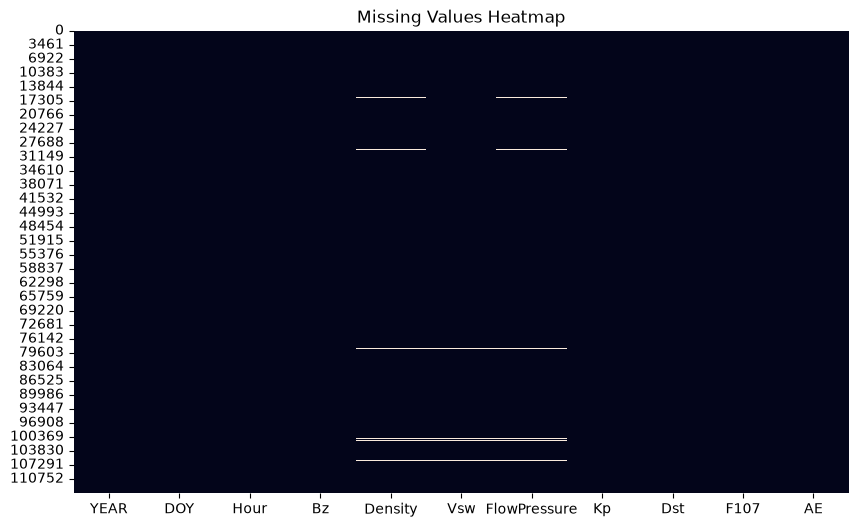

In [34]:

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [35]:
df[df["Bz"].isna()]

,YEAR,DOY,Hour,Bz,Density,Vsw,FlowPressure,Kp,Dst,F107,AE
32657,2016,266,17,NaN,3.7,465.0,1.37,0,3,85.7,35
41130,2017,253,18,NaN,NaN,NaN,NaN,20,-43,101.6,84
41131,2017,253,19,NaN,NaN,NaN,NaN,20,-38,101.6,161
41132,2017,253,20,NaN,NaN,NaN,NaN,20,-45,101.6,203
41133,2017,253,21,NaN,NaN,NaN,NaN,30,-49,101.6,369
...,...,...,...,...,...,...,...,...,...,...,...
113130,2025,331,18,NaN,NaN,NaN,NaN,43,-11,117.7,319
113131,2025,331,19,NaN,NaN,NaN,NaN,43,-6,117.7,207
113132,2025,331,20,NaN,NaN,NaN,NaN,43,-3,117.7,679
113133,2025,331,21,NaN,NaN,NaN,NaN,43,-8,117.7,420


In [36]:
df[df["Density"].isna()].head(20)

,YEAR,DOY,Hour,Bz,Density,Vsw,FlowPressure,Kp,Dst,F107,AE
115,2013,5,19,-0.6,NaN,298.0,NaN,3,6,140.3,94
116,2013,5,20,-1.1,NaN,307.0,NaN,3,7,140.3,31
3308,2013,138,20,-1.9,NaN,403.0,NaN,33,-34,135.2,575
4845,2013,202,21,-1.1,NaN,388.0,NaN,13,-5,112.9,167
4846,2013,202,22,-0.1,NaN,392.0,NaN,13,-4,112.9,106
6716,2013,280,20,-0.4,NaN,288.0,NaN,7,-12,111.8,57
6739,2013,281,19,-2.3,NaN,321.0,NaN,50,5,111.7,294
6740,2013,281,20,-2.2,NaN,351.0,NaN,50,17,111.7,652
11152,2014,100,16,-0.7,NaN,378.0,NaN,3,-5,137.3,46
14132,2014,224,20,-5.6,NaN,428.0,NaN,43,-14,106.8,682


In [37]:
df[df["Density"].isna()].head()

,YEAR,DOY,Hour,Bz,Density,Vsw,FlowPressure,Kp,Dst,F107,AE
115,2013,5,19,-0.6,NaN,298.0,NaN,3,6,140.3,94
116,2013,5,20,-1.1,NaN,307.0,NaN,3,7,140.3,31
3308,2013,138,20,-1.9,NaN,403.0,NaN,33,-34,135.2,575
4845,2013,202,21,-1.1,NaN,388.0,NaN,13,-5,112.9,167
4846,2013,202,22,-0.1,NaN,392.0,NaN,13,-4,112.9,106


In [38]:
df[df["Density"].isna()].tail()

,YEAR,DOY,Hour,Bz,Density,Vsw,FlowPressure,Kp,Dst,F107,AE
113132,2025,331,20,NaN,NaN,NaN,NaN,43,-3,117.7,679
113133,2025,331,21,NaN,NaN,NaN,NaN,43,-8,117.7,420
113134,2025,331,22,NaN,NaN,NaN,NaN,43,-10,117.7,414
113414,2025,343,14,-2.3,NaN,NaN,NaN,13,-3,178.1,151
113606,2025,351,14,2.9,NaN,NaN,NaN,27,20,114.7,304


In [39]:
df[df["Vsw"].isna()]

,YEAR,DOY,Hour,Bz,Density,Vsw,FlowPressure,Kp,Dst,F107,AE
41130,2017,253,18,NaN,NaN,NaN,NaN,20,-43,101.6,84
41131,2017,253,19,NaN,NaN,NaN,NaN,20,-38,101.6,161
41132,2017,253,20,NaN,NaN,NaN,NaN,20,-45,101.6,203
41133,2017,253,21,NaN,NaN,NaN,NaN,30,-49,101.6,369
41134,2017,253,22,NaN,NaN,NaN,NaN,30,-58,101.6,368
...,...,...,...,...,...,...,...,...,...,...,...
113132,2025,331,20,NaN,NaN,NaN,NaN,43,-3,117.7,679
113133,2025,331,21,NaN,NaN,NaN,NaN,43,-8,117.7,420
113134,2025,331,22,NaN,NaN,NaN,NaN,43,-10,117.7,414
113414,2025,343,14,-2.3,NaN,NaN,NaN,13,-3,178.1,151


In [40]:
df["Datetime"] = (
    pd.to_datetime(df["YEAR"], format="%Y")
    + pd.to_timedelta(df["DOY"] - 1, unit="D")
    + pd.to_timedelta(df["Hour"], unit="h")
)

In [41]:
df[["YEAR", "DOY", "Hour", "Datetime"]].head()

,YEAR,DOY,Hour,Datetime
0,2013,1,0,2013-01-01 00:00:00
1,2013,1,1,2013-01-01 01:00:00
2,2013,1,2,2013-01-01 02:00:00
3,2013,1,3,2013-01-01 03:00:00
4,2013,1,4,2013-01-01 04:00:00


In [42]:
df.set_index("Datetime", inplace=True)

In [43]:
df.head()

,YEAR,DOY,Hour,Bz,Density,Vsw,FlowPressure,Kp,Dst,F107,AE
Datetime,,,,,,,,,,,
2013-01-01 00:00:00,2013,1,0,-0.2,1.9,358.0,0.49,7,4,113.9,11
2013-01-01 01:00:00,2013,1,1,-0.2,2.1,355.0,0.52,7,4,113.9,10
2013-01-01 02:00:00,2013,1,2,-0.1,1.8,359.0,0.44,7,3,113.9,8
2013-01-01 03:00:00,2013,1,3,0.2,1.9,352.0,0.44,3,2,113.9,9
2013-01-01 04:00:00,2013,1,4,0.6,2.0,351.0,0.47,3,1,113.9,12


In [45]:
df.index.is_monotonic_increasing #to check if its in increasing order

True

In [47]:
df.index.duplicated().sum() #no duplicated time frame

np.int64(0)

In [48]:
print("Shape:", df.shape)

print("\nDate Range:")
print(df.index.min())
print(df.index.max())

print("\nSorted:", df.index.is_monotonic_increasing)

print("\nDuplicate timestamps:", df.index.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (114192, 11)

Date Range:
2013-01-01 00:00:00
2026-01-10 23:00:00

Sorted: True

Duplicate timestamps: 0

Missing Values:
YEAR               0
DOY                0
Hour               0
Bz               352
Density         1121
Vsw              711
FlowPressure    1129
Kp                 0
Dst                0
F107              48
AE                 0
dtype: int64


In [49]:
continuous_cols = ["Bz", "Density", "Vsw", "FlowPressure", "F107"]

df[continuous_cols] = df[continuous_cols].interpolate(method="time")

In [57]:
#we used this technique as these values are continuous with very small difference(<1%)! Thus it was valid to interpolate

In [61]:
#for edge cases..copies value in edges if missing from either next or before depending ki sbse last wala missing hai ya sbse front wala
df[continuous_cols] = (
    df[continuous_cols]
    .ffill()
    .bfill()
)
# ffill() copies the previous valid value forward
# bfill() copies the next valid value backward

In [62]:
df.isnull().sum()

YEAR            0
DOY             0
Hour            0
Bz              0
Density         0
Vsw             0
FlowPressure    0
Kp              0
Dst             0
F107            0
AE              0
dtype: int64

In [63]:
print("Shape:", df.shape)

print("\nDate Range:")
print(df.index.min())
print(df.index.max())

print("\nSorted:", df.index.is_monotonic_increasing)

print("\nDuplicate timestamps:", df.index.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (114192, 11)

Date Range:
2013-01-01 00:00:00
2026-01-10 23:00:00

Sorted: True

Duplicate timestamps: 0

Missing Values:
YEAR            0
DOY             0
Hour            0
Bz              0
Density         0
Vsw             0
FlowPressure    0
Kp              0
Dst             0
F107            0
AE              0
dtype: int64


In [70]:
"""
## Final Dataset Validation

- Total Rows: 114192
- Total Columns: 11
- Date Range: 2013-01-01 to 2026-01-10
- Duplicate Timestamps: 0
- Missing Values: 0
- Dataset Status: Ready for feature engineering and model development
"""

'\n## Final Dataset Validation\n\n- Total Rows: 114192\n- Total Columns: 11\n- Date Range: 2013-01-01 to 2026-01-10\n- Duplicate Timestamps: 0\n- Missing Values: 0\n- Dataset Status: Ready for feature engineering and model development\n'

In [71]:
df.to_csv("data/processed/omni_clean.csv")

In [72]:
df.to_pickle("data/processed/omni_clean.pkl")